# Results Analysis — Thief Agent (M5-7)

Analysis of the strategy track's committed instruments: the arena round-robin and champion gate,
the CI-blocking DoD win-rate floor, the M5-4 genetic-tuning run, and a weight-sensitivity sweep
around the deployed vector. **Every number regenerates from committed config**
(`config/arena.json`, `config/ga.json`, `config/ga_weights.json`) — nothing is hand-entered.

**Metric conventions.** Belief error against ground truth is $e_t = 1 - P_t(c^*)$, where
$P_t(c^*)$ is the tracking belief's mass on the opponent's true cell at step $t$ (the M3-3
identity; referee mode only — live play never sees $c^*$). GA fitness is the candidate's
win-rate for its role over a fresh scenario-seed suite,
$f(\theta) = \frac{1}{|S|} \sum_{s \in S} \mathbb{1}[\text{win}_s(\theta)]$,
with $S$ disjoint from the DoD seeds (the gate is never a training target).

**Sources.**
[1] Y. Segal, *Distributed Cops-and-Robbers over a P2P Network*, v3.0.0 — ch. 6 (strategy
module), §6.3.1 (the "your own heuristic algorithm" track). \
[2] `docs/adr/0005-strategy-track.md` — belief+search over RL (decision record). \
[3] `docs/adr/0002-reference-reuse.md` — HW6 genetic-algorithm salvage attribution. \
[4] `docs/PRD_police_brain.md` §2–§4 / `docs/PRD_thief_brain.md` §2–§3 — DoD definition,
scenario suite, perception-held-fixed disclosure.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

from copthief_core.domain.rules import Outcome
from copthief_core.sdk.arena import champion_regression, load_champions, run_round_robin
from copthief_core.sdk.arena_config import load_arena_config
from copthief_core.sdk.simulation import SimulationSdk
from copthief_core.strategy.scenarios import scenario_suite

ROOT = Path.cwd() if (Path.cwd() / "config").is_dir() else Path.cwd().parent
sdk = SimulationSdk(ROOT / "config")
arena = load_arena_config(ROOT / "config" / "arena.json")
ga = json.loads((ROOT / "config" / "ga_weights.json").read_text(encoding="utf-8"))
print("arena seeds:", list(arena.seeds), "| GA role:", ga["role"], "vs", ga["opponent"])

arena seeds: [1, 2, 3, 4, 5, 6, 7, 8] | GA role: thief vs ref-police


## Arena round-robin — per-role standings and the champion gate

Per-role rosters (a role brain only ever enters its own side, PRD_police_brain §4) over the
committed seeded scenario suite; the champion pin is the CI regression gate (CLAUDE.md §5).

In [2]:
report = run_round_robin(sdk, config=arena)
print(f"{'brain':<20}{'role':<9}{'games':>6}{'wins':>6}{'points':>8}")
print("-" * 49)
for s in report.standings:
    print(f"{s.brain:<20}{s.role:<9}{s.games:>6}{s.wins:>6}{s.points:>8}")
problems = champion_regression(report, load_champions(ROOT / "config" / "arena_champion.json"))
print()
print("champion gate:", problems if problems else "GREEN")

brain               role      games  wins  points
-------------------------------------------------
ref-police          police       32    17     415
greedy-manhattan    police       32     8     280
random              police       32     3     205
greedy-manhattan    thief        24    21     225
thief-brain         thief        24    21     225
ref-thief           thief        24    20     220
random              thief        24     6     150

champion gate: GREEN


## DoD win-rate floor (CI-blocking)

The configured head-to-head series against the re-derived reference heuristic — the same series
`tests/integration/test_arena_dod.py` runs as a permanent gate.

In [3]:
for dod in arena.dod_series:
    scenarios = scenario_suite(
        sdk.constitution, seeds=dod.seeds, min_separation=arena.scenario_min_separation
    )
    results = sdk.scenario_series(
        police=arena.spec_for(dod.police),
        thief=arena.spec_for(dod.thief),
        scenarios=scenarios,
        police_options=arena.options_for(dod.police),
        thief_options=arena.options_for(dod.thief),
    )
    winning = Outcome.COP_CAPTURE if dod.wins_role == "police" else Outcome.THIEF_SURVIVAL
    wins = sum(r.outcome is winning for r in results)
    rate = wins / len(results)
    verdict = "PASS" if rate >= dod.min_win_rate else "FAIL"
    print(
        f"{dod.label}\n  {wins}/{len(results)} = {rate:.1%} (floor {dod.min_win_rate:.0%}) -> {verdict}"
    )

M5-3 thief DoD - ThiefBrain vs the reference heuristic
  27/32 = 84.4% (floor 60%) -> PASS


## Genetic-tuning fitness curve (M5-4)

The committed offline run (`config/ga_weights.json`, written by `scripts/ga_run.py`): elitism
makes the best curve non-decreasing by construction; the dotted line is the default (untuned)
weight vector's fitness on the same suite.

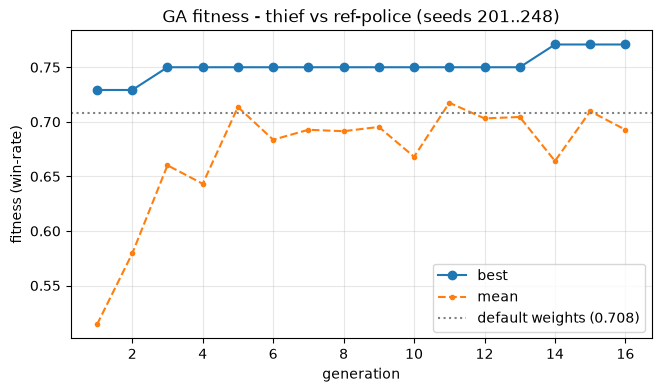

default 0.708 -> evolved 0.792


In [4]:
history = ga["history"]
generations = list(range(1, len(history) + 1))
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(generations, [g["best"] for g in history], marker="o", label="best")
ax.plot(generations, [g["mean"] for g in history], marker=".", linestyle="--", label="mean")
ax.axhline(
    ga["default_fitness"],
    color="grey",
    linestyle=":",
    label=f"default weights ({ga['default_fitness']:.3f})",
)
ax.set_xlabel("generation")
ax.set_ylabel("fitness (win-rate)")
ax.set_title(
    f"GA fitness - {ga['role']} vs {ga['opponent']} "
    f"(seeds {ga['fitness_seeds'][0]}..{ga['fitness_seeds'][-1]})"
)
ax.legend()
ax.grid(alpha=0.3)
plt.show()
print(f"default {ga['default_fitness']:.3f} -> evolved {ga['evolved_fitness']:.3f}")

## Weight sensitivity around the deployed vector

One gene at a time, swept across its GA search box while every other deployed weight holds; the
response is the DoD win-rate on the committed gate suite. The dotted vertical line marks the
deployed value. Flat regions mean the gene box is forgiving; cliffs mark load-bearing weights.

w_distance = 0.500 -> DoD 34.4%
w_distance = 1.875 -> DoD 34.4%
w_distance = 3.250 -> DoD 68.8%
w_distance = 4.625 -> DoD 81.2%
w_distance = 6.000 -> DoD 87.5%


ramp_start_fraction = 0.300 -> DoD 78.1%
ramp_start_fraction = 0.462 -> DoD 78.1%
ramp_start_fraction = 0.625 -> DoD 78.1%
ramp_start_fraction = 0.787 -> DoD 84.4%
ramp_start_fraction = 0.950 -> DoD 84.4%


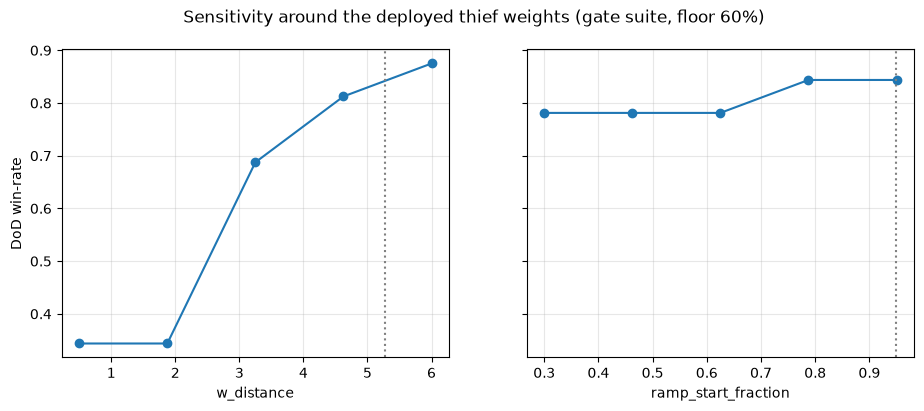

In [5]:
ga_config = json.loads((ROOT / "config" / "ga.json").read_text(encoding="utf-8"))
dod = arena.dod_series[0]
scenarios = scenario_suite(
    sdk.constitution, seeds=dod.seeds, min_separation=arena.scenario_min_separation
)
mine = ga["role"]
my_name = dod.police if mine == "police" else dod.thief
their_name = dod.thief if mine == "police" else dod.police
winning = Outcome.COP_CAPTURE if mine == "police" else Outcome.THIEF_SURVIVAL
base_options = arena.options_for(my_name)
sweep_genes = ["w_distance", "ramp_start_fraction"]
POINTS = 5
fig, axes = plt.subplots(1, len(sweep_genes), figsize=(11, 4), sharey=True)
for ax, gene in zip(axes, sweep_genes, strict=True):
    low, high = ga_config["genes"][gene]
    values = [low + i * (high - low) / (POINTS - 1) for i in range(POINTS)]
    rates = []
    for value in values:
        options = {**base_options, gene: value}
        results = sdk.scenario_series(
            police=arena.spec_for(dod.police),
            thief=arena.spec_for(dod.thief),
            scenarios=scenarios,
            police_options=options if mine == "police" else arena.options_for(their_name),
            thief_options=arena.options_for(their_name) if mine == "police" else options,
        )
        rates.append(sum(r.outcome is winning for r in results) / len(results))
    ax.plot(values, rates, marker="o")
    if gene in base_options:
        ax.axvline(base_options[gene], color="grey", linestyle=":")
    ax.set_xlabel(gene)
    ax.grid(alpha=0.3)
    for value, rate in zip(values, rates, strict=True):
        print(f"{gene} = {value:.3f} -> DoD {rate:.1%}")
axes[0].set_ylabel("DoD win-rate")
fig.suptitle(
    f"Sensitivity around the deployed {mine} weights (gate suite, floor {dod.min_win_rate:.0%})"
)
plt.show()

## Template-bank A/B (M5-6) — the committed measured table

Rendered verbatim from `docs/evidence/m5-template-ab.md` (regenerable via
`scripts/deception_ab.py`; referee mode — the efficacy metric needs ground truth).

In [6]:
from IPython.display import Markdown

Markdown((ROOT / "docs" / "evidence" / "m5-template-ab.md").read_text(encoding="utf-8"))

# M5-6 template-bank A/B - deception efficacy (referee mode)

> Generated by `uv run python scripts/deception_ab.py` (deterministic;
> regenerate, never hand-edit). Efficacy = mean belief-error induced on the
> tracking belief per hint (error = 1 - P(true cell), the M3-3 identity),
> split by SEALED verdict - measurable only in referee mode, where truth is
> known. Wording is neutral to our own closed-vocabulary parser by
> construction; measured differences come from parse survival under the
> signed word cap and the decoy policy. Thief: `copthief_thief.brain:ThiefBrain`.

| bank | games | thief wins | lies | truths | error/lie | error/truth |
|---|---|---|---|---|---|---|
| classic | 32 | 20 | 31 | 845 | +0.000042 | -0.006730 |
| terse | 32 | 20 | 31 | 845 | +0.000042 | -0.006730 |

**Winner (highest induced error per lie, survivals tiebreak): `classic`** - shipped in `game.toml [strategy] hint_bank`.


## Reading the results

- The **arena** table shows `thief-brain` at the top of its role tie-group; the champion pin
  honestly stays `greedy-manhattan` (a tie is not a dethroning — M5-3 precedent). The **DoD
  floor** holds at 84% with the deployed evolved weights (permanent CI gate; the greedy tie is
  broken, 27/32 vs 25/32).
- The **GA curve** improves (0.708→0.792 on training) and validates off-suite net-positive
  (DoD 78%→84%, holdout 84%→81% — disclosed in `docs/evidence/m5-ga.md` and PR #24).
- The **A/B table** above is candid: banks measure identical against our own closed-vocabulary
  parser (wording-neutral by construction), and lie efficacy is real but tiny — the timing
  policy fires when the exact-Bayes tracker is already near-certain. Both findings feed the
  final report's strategy narrative.